# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Business Objective:
Help a used car dealership make informed decisison by identifying which attributes of a used car most stronlgly influence its sale price.

#### Business Success Criteria:
The analysis is sconsidered successful if it produces clear, actionable recommendationss that the dealership can use to decide which types of cars to stock.

#### Resources:
A dataset of 426K cars sourced from Kaggle (a subset of 3-million record original dataset).

#### Requirements:
* No additional data collection is planned.
* Results must be delivered as a Jupyter notebook with accompanying README summary.
* Findings must be in plain-langauage recommendations for a non-technical audience.

#### Data Mining Goal:
* Build a supervised regression model that predicts used car prices based on vehicle attributes. The model must quantify the relative importance and direction of the different features's effect on the car price.

#### Data Mining Success Criteria:
* Low RMSE on held-out data via cross-validation

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Collect Initial Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Confirm successful load by previewing the first few rows
print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 426,880 rows x 18 columns


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


#### Describe Data

In [2]:
df.dropna().head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

#### Data Description Report:
* There are 2 identifiers: `id` and `VIN` (Vehicle Identification Number) which should be a unique, 17-character alphanumeric fingerprint assigned to every motor vehicle.
* The Target is the `price` column
* 2 Numeric Features: 
1. `year` and 
2. `odometer`
* 14 Categorical Features: 
1. `region`
2. `manufacturer`
3. `model`
4. `condition`
5. `cylinders`
6. `fuel`
7. `title_status`
8. `transmission`
9. `drive`
10. `size`
11. `type`
13. `paint_color`
14. `state`



In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})\
  .query('`Missing Count` > 0')\
  .sort_values('Missing %', ascending=False)

,Missing Count,Missing %
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


In [5]:
df['price'].describe()
print(f"Zero prices: {(df['price'] == 0).sum():,}")
print(f"Prices > $100,000: {(df['price'] > 100_000).sum():,}")
print(f"Max price: ${df['price'].max():,.0f}")

Zero prices: 32,895
Prices > $100,000: 655
Max price: $3,736,928,711


#### Data Quality Report
* 72% of `size` data is missing. I will need to drop it as the available remaining data won't be useful.
* Although `VIN` number encodes specific vehicle information but 38% of them are already missing and decoding it requires manufacturer-specific lookup table that is not available to use. I will drop this column and rely on the `id` as the identifier.
* 32,895 listings have a price of $0. These are important missing data so the records need to be removed.
* 174,104 (41%) of the records have missing `condition`, but we should keep it although that means that we would have to drop the missing records which would leave us with 142,117 records (33.3% of the original dataset) but that should remain sufficient for robust modeling.
* Odometer max was 10,000,000 which is clearly an error

In [6]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [7]:
# Check if id is truly unique
print(f"Total rows: {len(df)}")
print(f"Unique IDs: {df['id'].nunique()}")
print(f"Duplicates: {df['id'].duplicated().sum()}")

Total rows: 426880
Unique IDs: 426880
Duplicates: 0


In [8]:
# Check if there are records with zero as the Price
df['price'].describe()
print(f"Zero prices: {(df['price'] == 0).sum():,}")
print(f"Prices > $100,000: {(df['price'] > 100_000).sum():,}")
print(f"Max price: ${df['price'].max():,.0f}")

Zero prices: 32,895
Prices > $100,000: 655
Max price: $3,736,928,711


In [9]:
# Check for the best approach to deal with the missing data by calculating how many rows would remains 
original = len(df)
print(f"Original:                    {original:,}  (100%)")

cols_to_drop = ['size', 'VIN', 'cylinders']
df_temp = df.drop(columns=cols_to_drop)
print(f"After dropping columns:      {len(df_temp):,}  ({len(df_temp)/original*100:.1f}%)")


missing_temp = df_temp.isnull().sum()
missing__temp_pct = (df_temp.isnull().sum() / len(df_temp) * 100).round(2)
pd.DataFrame({'Missing Count': missing_temp, 'Missing %': missing__temp_pct})\
  .query('`Missing Count` > 0')\
  .sort_values('Missing %', ascending=False)

Original:                    426,880  (100%)
After dropping columns:      426,880  (100.0%)


,Missing Count,Missing %
condition,174104,40.79
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24
odometer,4400,1.03
fuel,3013,0.71
transmission,2556,0.60


In [10]:
df_temp = df_temp.dropna()
print(f"After dropping NaN rows:     {len(df_temp):,}  ({len(df_temp)/original*100:.1f}%)")

After dropping NaN rows:     142,117  (33.3%)


#### Data Exploration Report
* Price Distribution is Heavily Right-Skewed. The distribution of used car prices is not normal. It has extreme outliers. Maximum is $3.7 billion. The median price is $12,995 while the mean is $54,255 due to these outliers.
* Interestingly, vehicles listed as 'good' show a higher median price than those listed as 'excellent' or 'like new'. This suggests that condition alone does not fully explain price. Vehicle type and other features likely play a role. A multivariate regression model will probably be better than relying on any single feature.
* Price tends to decrease as mileage and vehicle age increase, which is expected.
* `title_status` has a clear impact on the price and will be an important feature to retain

In [11]:
df['price'].describe()

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

In [12]:
# How many cars are priced at $0 or very low?
print(f"Price = $0:          {(df['price'] == 0).sum():,}")
print(f"Price < $500:        {(df['price'] < 500).sum():,}")

# How many cars are priced suspiciously high?
print(f"Price > $100,000:    {(df['price'] > 100000).sum():,}")
print(f"Price > $200,000:    {(df['price'] > 200000).sum():,}")
print(f"Price > $1,000,000:  {(df['price'] > 1000000).sum():,}")

Price = $0:          32,895
Price < $500:        42,094
Price > $100,000:    655
Price > $200,000:    124
Price > $1,000,000:  53


In [13]:
sns.set_theme(style='whitegrid', palette='muted')

# Filter out price outliers for cleaner visualizations
# Keeping prices between $500 and $100,000
df_viz = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
df_viz['age'] = 2024 - df_viz['year']

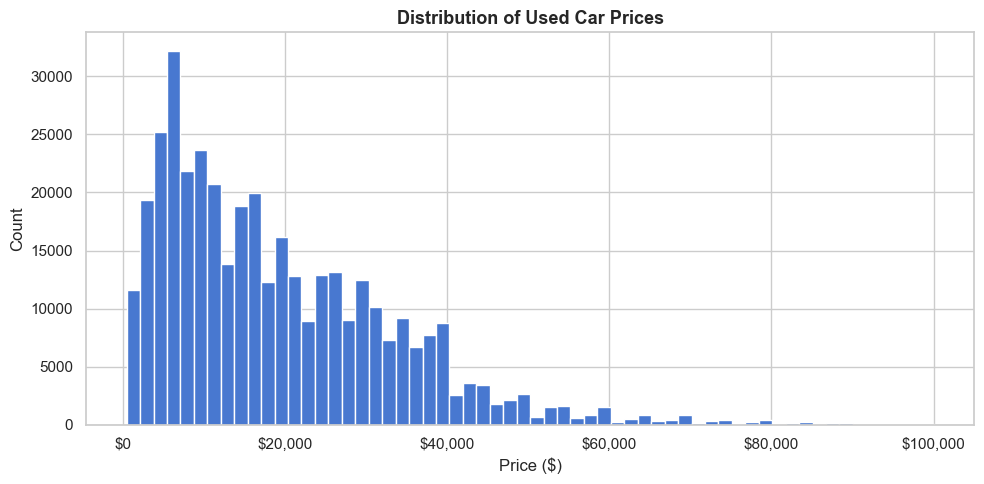

In [14]:
# Price distribution — reveals skewness and outliers
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_viz['price'], bins=60)
ax.set_title('Distribution of Used Car Prices', fontsize=13, fontweight='bold')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [15]:
# Price Vs Condition
df['condition'].unique()

array([nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage'],
      dtype=object)

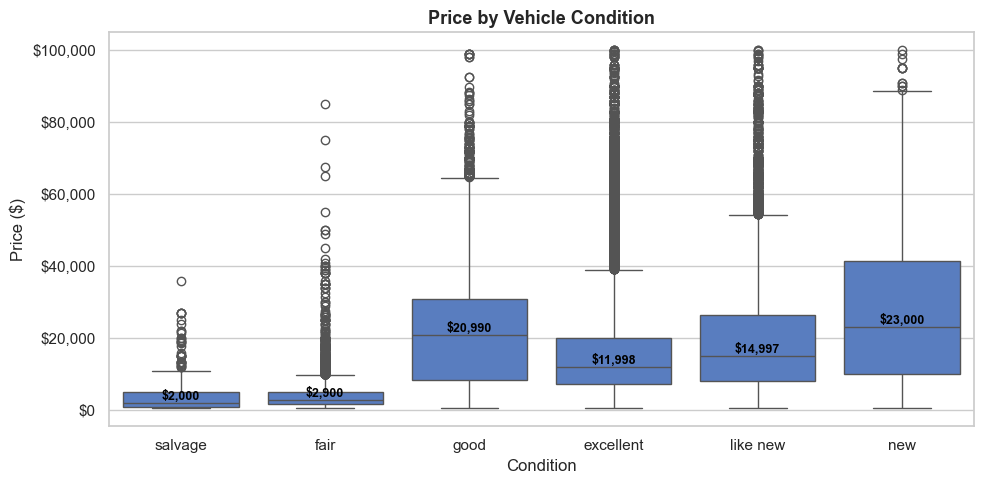

In [16]:
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_viz, x='condition', y='price', order=condition_order, ax=ax)

# Add median labels on top of each box
medians = df_viz.groupby('condition')['price'].median()
for i, condition in enumerate(condition_order):
    median_val = medians[condition]
    ax.text(i, median_val, f'${median_val:,.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9, color='black')

ax.set_title('Price by Vehicle Condition', fontsize=13, fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [17]:
# Price Vs Title Status
df['title_status'].unique()

array([nan, 'clean', 'rebuilt', 'lien', 'salvage', 'missing',
       'parts only'], dtype=object)

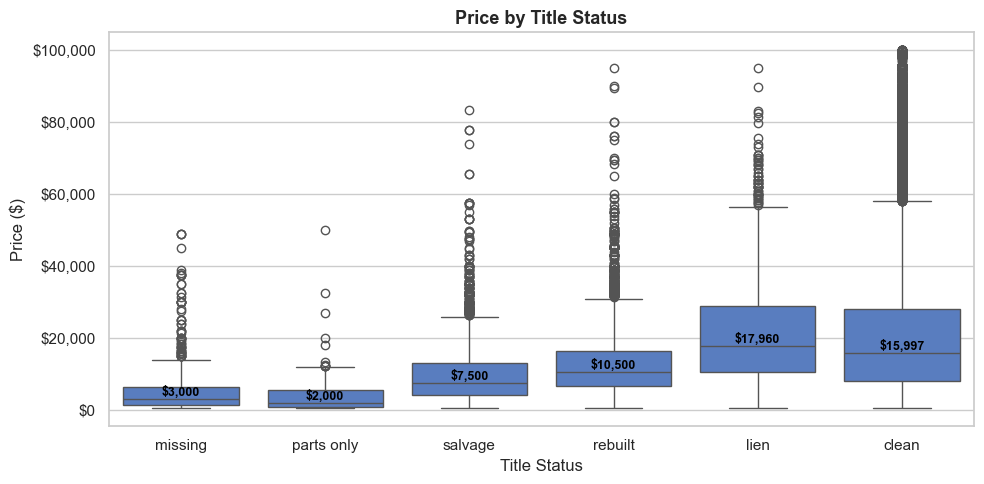

In [18]:

title_status_order = ['missing', 'parts only', 'salvage', 'rebuilt', 'lien' , 'clean']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_viz, x='title_status', y='price', order=title_status_order, ax=ax)
# Add median labels on top of each box
medians = df_viz.groupby('title_status')['price'].median()
for i, title_status in enumerate(title_status_order):
    median_val = medians[title_status]
    ax.text(i, median_val, f'${median_val:,.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9, color='black')
ax.set_title('Price by Title Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Title Status')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

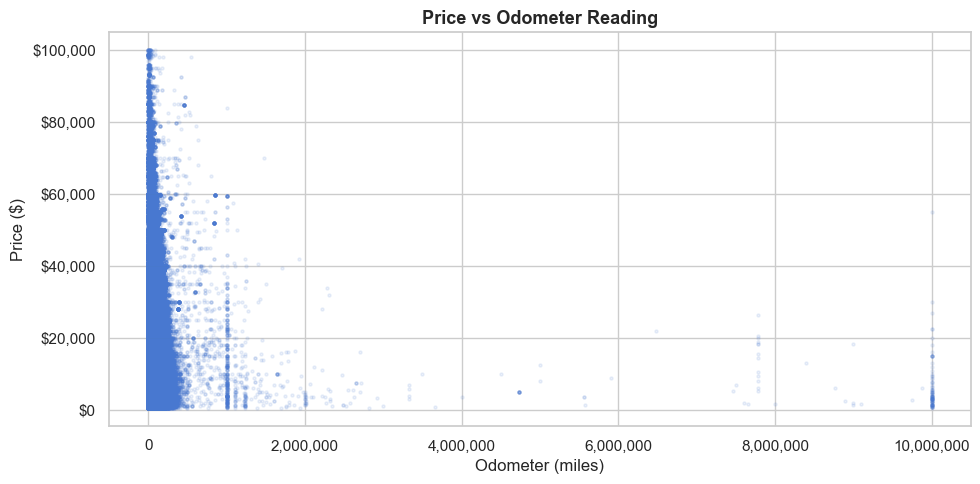

In [19]:
# Price Vs Odometer
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_viz['odometer'], df_viz['price'], alpha=0.1, s=5)
ax.set_title('Price vs Odometer Reading', fontsize=13, fontweight='bold')
ax.set_xlabel('Odometer (miles)')
ax.set_ylabel('Price ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

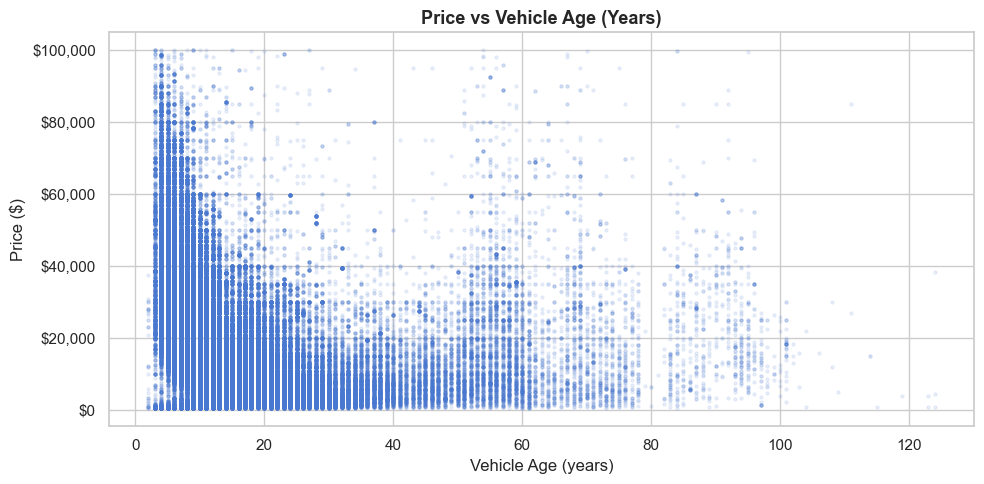

In [20]:
#Price vs Vehicle Age
df_viz['age'] = 2024 - df_viz['year']

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_viz['age'], df_viz['price'], alpha=0.1, s=5)
ax.set_title('Price vs Vehicle Age (Years)', fontsize=13, fontweight='bold')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

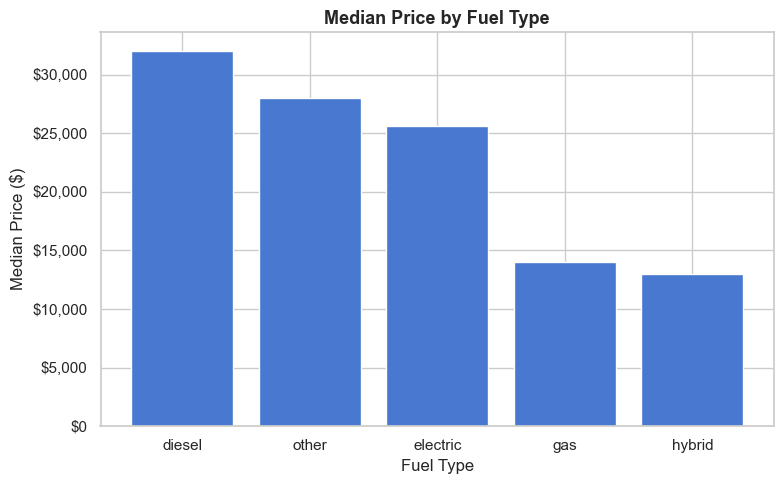

In [21]:
# Price Vs Fuel Type
fuel_median = df_viz.groupby('fuel')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fuel_median.index, fuel_median.values)
ax.set_title('Median Price by Fuel Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

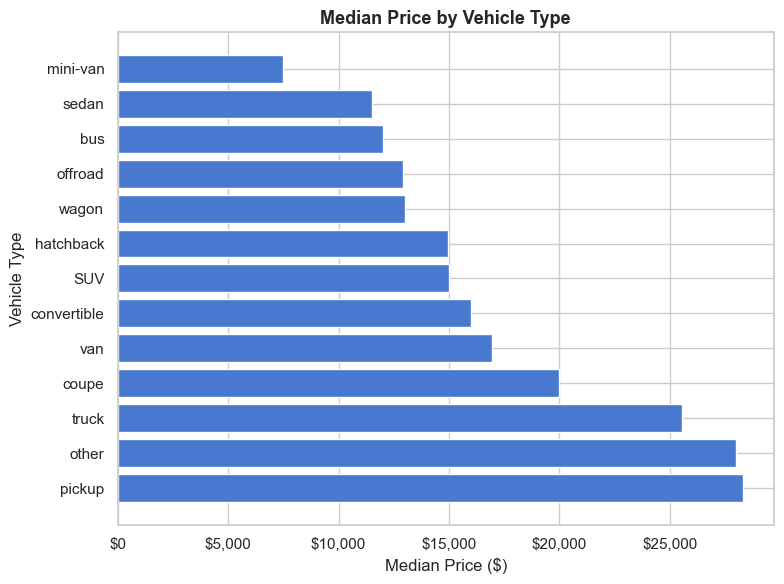

In [22]:
# Price Vs Vehicle Type
type_median = df_viz.groupby('type')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(type_median.index, type_median.values)
ax.set_title('Median Price by Vehicle Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Price ($)')
ax.set_ylabel('Vehicle Type')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

#### Select Data + Rationale for inclusion/exclusion
The following steps were taken to prepare the dataset for modeling.

---

1. Drop Irrelevant Columns 
- `id` : Unique identifier (not a predictive feature)
- `VIN` : Identifier with 37.7% missing values
- `size` : 71.8% missing (not recoverable)
- `cylinders` : 41.6% missing
- `region` : 404 unique values (too granular). `state` captures geography more cleanly

---

2. Drop Rows with Missing Values
After removing the most problematic columns, remaining rows with any missing values are dropped.
This retains **33.3% of the original dataset (142,117 records)**, which should be sufficient for robust modeling.

---

3. Remove Outliers by applying filters
- `price` (Filter applied: $2,000 – $50,000): Below $500 are likely errors; above $50,000 is only 3% of listings.
- `odometer` (Filter applied: ≤ 200,000 miles): Values above this are clearly erroneous.
- `year` (Filter applied: ≥ 1990): Older vehicles follow different pricing rules (antique/collector market).

---

4. Feature Engineering
- **`age`** is created as `2026 - year` to directly represent vehicle depreciation.
- **`year`** is dropped after `age` is created since they capture the same information.

---

5. Encoding Categorical Variables
Two encoding strategies are used depending on whether a natural order exists between categories:

**Ordinal Encoding**: used when categories have a meaningful order:
- `condition`: `salvage(0) → fair(1) → good(2) → excellent(3) → like new(4) → new(5)`
- `title_status`: `parts only(0) → missing(1) → salvage(2) → rebuilt(3) → lien(4) → clean(5)`

**One-Hot Encoding**: used when no natural order exists between categories:
- Applied to: `manufacturer`, `fuel`, `transmission`, `drive`, `type`, `paint_color`, `state`
- `model` is dropped entirely due to its 29,649 unique values which would add noise rather than signal

---

6. Log-Transform the Target Variable (`price`)
- Used car prices are heavily right-skewed
- Linear regression assumes the target is approximately normally distributed
- Applying `log(price)` compresses the scale, reduces the impact of extreme values, and produces a near-normal distribution

---

7. Scale Numeric Features
- `age` and `odometer` are scaled using **StandardScaler** (mean = 0, standard deviation = 1)

In [23]:
# These columns add no predictive value:
# - 'id': unique identifier, not a feature
# - 'VIN': identifier, 37.7% missing anyway
# - 'size': 71.8% missing, not recoverable
# - 'cylinders': 41.6% missing
# - 'region': superseded by 'state' which is cleaner

cols_to_drop = ['id', 'VIN', 'size', 'cylinders', 'region']
df.drop(columns=cols_to_drop, inplace=True)

In [24]:
# Remove Rows with Missing Values
# drop rows with any missing values
print(f"Before: {len(df):,}")
original_length = len(df)
df.dropna(inplace=True)
print(f"After:  {len(df):,}  ({len(df)/original_length*100:.1f}% of original)")

Before: 426,880
After:  142,117  (33.3% of original)


In [25]:
# Remove Price Outliers
# $0 prices are data entry errors
# Prices above $50,000 are small % of listings and will distort modeling
print(f"Before: {len(df):,}")
df = df[(df['price'] >= 2000) & (df['price'] <= 50000)]
print(f"After:  {len(df):,}")

Before: 142,117
After:  130,000


In [26]:
# Remove Odometer Outliers
# Odometer max was 10,000,000 which is clearly an error
# Keeping values up to 200,000 miles covers even extreme high-mileage cases
print(f"Before: {len(df):,}")
df = df[df['odometer'] <= 200000]
print(f"After:  {len(df):,}")

Before: 130,000
After:  122,072


In [27]:
# Filter classic/antique cars
# Year min was 1900. Since classic/antique cars follow different pricing rules, we will filter them out
# Keeping 1990+ focuses on the mainstream used car market
print(f"Before: {len(df):,}")
df = df[df['year'] >= 1990]
print(f"After:  {len(df):,}")

Before: 122,072
After:  118,510


In [28]:
# 'Age' instead of 'Year'
# 'year' as a raw number is less intuitive for a model than age
df['age'] = 2026 - df['year']

# We can now drop 'year' since 'age' captures the same information
df.drop(columns=['year'], inplace=True)

In [29]:
#Encode Categorical Variables
# 'condition' has a clear order from worst to best
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']

# Map each level to a number preserving the order
condition_map = {c: i for i, c in enumerate(condition_order)}
df['condition_encoded'] = df['condition'].map(condition_map)
df.drop(columns=['condition'], inplace=True)

# title_status also has an implied order by desirability
title_order = ['parts only', 'missing', 'salvage', 'rebuilt', 'lien', 'clean']
title_map = {t: i for i, t in enumerate(title_order)}
df['title_status_encoded'] = df['title_status'].map(title_map)
df.drop(columns=['title_status'], inplace=True)

In [30]:
# These columns have no meaningful order between categories
nominal_cols = ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'paint_color', 'state']

# drop_first=True drops one category per column to avoid multicollinearity
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [31]:
# dropping 'model' since it has 29,649 unique values (one-hot encoding would create thousands of columns)
df.drop(columns=['model'], inplace=True)

In [32]:
# Log-Transform the 'price' Variable as it is heavily right-skewed
df['log_price'] = np.log(df['price'])
df.drop(columns=['price'], inplace=True)

In [33]:
# Scale numeric values
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'odometer']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [34]:
# Final Dataset
print(f"Final shape: {df.shape}")
print(f"\nAny nulls remaining: {df.isnull().sum().sum()}")
print(f"\nTarget variable (log_price) distribution:")
print(df['log_price'].describe())


df.head()

Final shape: (118510, 124)

Any nulls remaining: 0

Target variable (log_price) distribution:
count    118510.000000
mean          9.532720
std           0.743734
min           7.600902
25%           8.983440
50%           9.615472
75%          10.165467
max          10.819778
Name: log_price, dtype: float64


,odometer,age,condition_encoded,title_status_encoded,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,...,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,log_price
31,0.731794,-0.152806,3,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,9.615805
32,-0.359203,0.024943,2,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,10.239603
33,-1.080298,-0.686050,2,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,10.451320
34,-0.831924,-1.219295,3,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,10.463103
35,-1.304682,-0.686050,2,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,10.308619


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### Modeling Technique
- Linear Regression: Basesline and starting point
- Ridge Regression (L2): Improves on baseline and keeps all features
- Lasso Regression (L1): Improves on baseline and performs feature selection

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

In [36]:
# Divide the data into training, validation, and test sets following the rule of thumb 60/20/20 splits.
from sklearn.model_selection import train_test_split

X = df.drop(columns=['log_price'])
y = df['log_price']

# Step 1: Split off 20% for test set first
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Split the remaining 80% into 60% train and 20% validation
# 0.25 x 80% = 20% of the full dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Training set:    {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set:  {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:        {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set:    71,106 rows  (60%)
Validation set:  23,702 rows  (20%)
Test set:        23,702 rows  (20%)


In [37]:
# define the pipeline

# Linear Regression — baseline, no regularization
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

# Ridge — L2 regularization
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

# Lasso — L1 regularization
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso())
])

In [38]:
# Establish baseline MSE for each model before any tuning
for name, pipeline in [('Linear Regression', lr_pipeline),
                        ('Ridge',             ridge_pipeline),
                        ('Lasso',             lasso_pipeline)]:

    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=5,
                             scoring='neg_mean_squared_error')

    mse_scores = -scores   # convert from negative to positive
    print(f"{name}:")
    print(f"  CV MSE scores: {mse_scores.round(4)}")
    print(f"  Mean MSE:      {mse_scores.mean():.4f}")
    print(f"  Std  MSE:      {mse_scores.std():.4f}")
    print()

Linear Regression:
  CV MSE scores: [0.1146 0.1133 0.1138 0.1138 0.117 ]
  Mean MSE:      0.1145
  Std  MSE:      0.0013

Ridge:
  CV MSE scores: [0.1146 0.1133 0.1138 0.1138 0.117 ]
  Mean MSE:      0.1145
  Std  MSE:      0.0013

Lasso:
  CV MSE scores: [0.5502 0.5483 0.553  0.5499 0.5616]
  Mean MSE:      0.5526
  Std  MSE:      0.0047



In [39]:
# Tune Hyperparameeters
# --- Ridge ---
ridge_params = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

ridge_finder = GridSearchCV(estimator=ridge_pipeline,
                            param_grid=ridge_params,
                            scoring='neg_mean_squared_error',
                            cv=5)
ridge_finder.fit(X_train, y_train)

print("Ridge Results:")
print(pd.DataFrame(ridge_finder.cv_results_)[['param_model__alpha',
                                               'mean_test_score',
                                               'std_test_score']])
print(f"Best alpha: {ridge_finder.best_params_}")
print(f"Best MSE:   {-ridge_finder.best_score_:.4f}")

Ridge Results:
   param_model__alpha  mean_test_score  std_test_score
0                0.01        -0.114483        0.001301
1                0.10        -0.114483        0.001301
2                1.00        -0.114483        0.001301
3               10.00        -0.114483        0.001301
4               50.00        -0.114485        0.001300
5              100.00        -0.114493        0.001299
6              500.00        -0.114635        0.001284
7             1000.00        -0.114863        0.001273
Best alpha: {'model__alpha': 10}
Best MSE:   0.1145


In [40]:
# Tune Hyperparameeters
# --- Lasso ---
lasso_params = {'model__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]}

lasso_finder = GridSearchCV(estimator=lasso_pipeline,
                            param_grid=lasso_params,
                            scoring='neg_mean_squared_error',
                            cv=5)
lasso_finder.fit(X_train, y_train)

print("Lasso Results:")
print(pd.DataFrame(lasso_finder.cv_results_)[['param_model__alpha',
                                               'mean_test_score',
                                               'std_test_score']])
print(f"Best alpha: {lasso_finder.best_params_}")
print(f"Best MSE:   {-lasso_finder.best_score_:.4f}")

Lasso Results:
   param_model__alpha  mean_test_score  std_test_score
0             0.00001        -0.114483        0.001305
1             0.00010        -0.114516        0.001316
2             0.00100        -0.114990        0.001298
3             0.01000        -0.123271        0.001562
4             0.10000        -0.192140        0.002130
5             1.00000        -0.552597        0.004745
Best alpha: {'model__alpha': 1e-05}
Best MSE:   0.1145


In [41]:
# Fit Linear Regression first since it has no GridSearchCV
lr_pipeline.fit(X_train, y_train)

models = {
    'Linear Regression': lr_pipeline,
    'Ridge':             ridge_finder,
    'Lasso':             lasso_finder
}

print("=== Validation Set MSE ===\n")
for name, model in models.items():
    val_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, val_pred)
    print(f"{name}:  Validation MSE = {mse:.4f}")

=== Validation Set MSE ===

Linear Regression:  Validation MSE = 0.1154
Ridge:  Validation MSE = 0.1154
Lasso:  Validation MSE = 0.1154


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

#### Approved Model
Ridge Regression is selected as the final model based on the following:
- Matches Linear Regression and Lasso in predictive performance (MSE ~0.1820)
- Applies meaningful regularization (alpha=10) unlike Lasso (alpha=0.0001)
- Retains all features with shrunk coefficients for complete interpretation

In [44]:
best_model = ridge_finder

test_pred = best_model.predict(X_test)
test_mse  = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)

print(f"=== Final Test Set Evaluation (Ridge) ===\n")
print(f"Test MSE  (log scale):    {test_mse:.4f}")
print(f"Test RMSE (log scale):    {test_rmse:.4f}")

# Convert back to dollar scale for business interpretation
test_pred_dollars = np.exp(test_pred)
y_test_dollars    = np.exp(y_test)
test_mse_dollars  = mean_squared_error(y_test_dollars, test_pred_dollars)
test_rmse_dollars = np.sqrt(test_mse_dollars)

print(f"\nTest MSE  (dollar scale): ${test_mse_dollars:,.0f}")
print(f"Test RMSE (dollar scale): ${test_rmse_dollars:,.0f}")


=== Final Test Set Evaluation (Ridge) ===

Test MSE  (log scale):    0.1173
Test RMSE (log scale):    0.3425

Test MSE  (dollar scale): $33,918,469
Test RMSE (dollar scale): $5,824


In [46]:
# Build coefficient DataFrame from the fitted model

feature_names = X.columns.tolist()
coefficients  = ridge_finder.best_estimator_.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': coefficients
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

#### Finding 1: Age and Mileage Are the Strongest Price Drivers
The two most influential features in the model are vehicle age and odometer reading. 
Both negatively correlated with price.

* Age (coefficient = -0.354): Each additional year of age reduces price by ~30%
* Odometer (coefficient = -0.244): Higher mileage significantly reduces price

**Recommendation:** Prioritize acquiring vehicles that are newer with less mileage.

=== Numeric Feature Coefficients ===
 feature  coefficient
     age    -0.344638
odometer    -0.247104


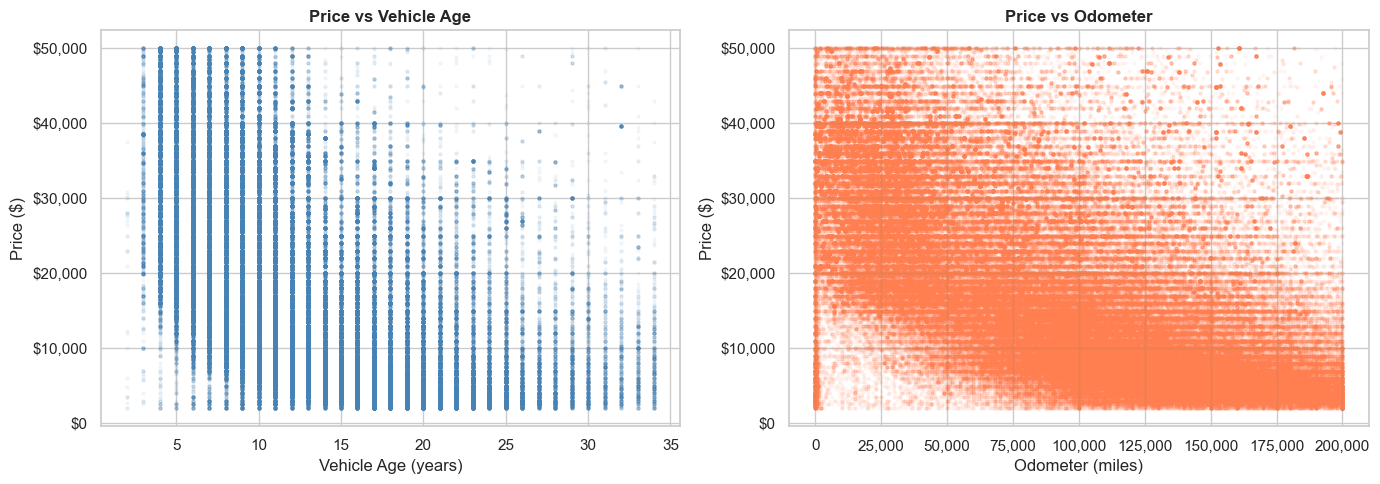

In [47]:
# Pull the two most influential numeric features

numeric_features = ['age', 'odometer', 'condition', 'title_status']
finding1 = coef_df[coef_df['feature'].isin(numeric_features)][['feature', 'coefficient']]
print("=== Numeric Feature Coefficients ===")
print(finding1.to_string(index=False))

# Visualize: scatter plots of age and odometer vs price
df_orig = pd.read_csv('data/vehicles.csv')
df_orig = df_orig[(df_orig['price'] >= 2000) & (df_orig['price'] <= 50000)]
df_orig = df_orig[df_orig['odometer'] <= 200000]
df_orig = df_orig[df_orig['year'] >= 1990]
df_orig['age'] = 2024 - df_orig['year']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_orig['age'], df_orig['price'],
                alpha=0.05, s=5, color='steelblue')
axes[0].set_title('Price vs Vehicle Age', fontweight='bold')
axes[0].set_xlabel('Vehicle Age (years)')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].scatter(df_orig['odometer'], df_orig['price'],
                alpha=0.05, s=5, color='coral')
axes[1].set_title('Price vs Odometer', fontweight='bold')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

#### Finding 2: Trucks and Pickups Command a Strong Premium

Vehicle type is one of the strongest categorical predictors of price.
Trucks and pickups have the highest positive coefficients and median prices in the dataset, while sedans and hatchbacks are at the lower end.

* Truck (Coefficient: +0.123): Median Price: $23,995
* Pickup (Coefficient: +0.081): Median Price: $27,990
* Hatchback (Coefficient: -0.038): Median Price: $14,990
* Sedan (Coefficient: -0.064): Median Price: $11,950


**Recommendation:** Focus inventory on trucks and pickups. 
They consistently command the highest prices. Sedans and mini-vans are the weakest performers and should represent a smaller share of inventory.

=== Vehicle Type Coefficients ===
       type  coefficient
      truck     0.123413
     pickup     0.080879
convertible     0.039599
      other     0.028301
      coupe     0.027947
        van     0.024753
    offroad     0.020947
   mini-van     0.009650
        bus     0.008221
      wagon    -0.009503
  hatchback    -0.038421
      sedan    -0.063734

=== Median Price by Vehicle Type ===
type
pickup         27990.0
other          26995.0
truck          23995.0
coupe          19990.0
van            16900.0
convertible    15500.0
SUV            14997.0
hatchback      14990.0
wagon          13400.0
bus            12900.0
offroad        12900.0
sedan          11950.0
mini-van        7995.0
Name: price, dtype: float64


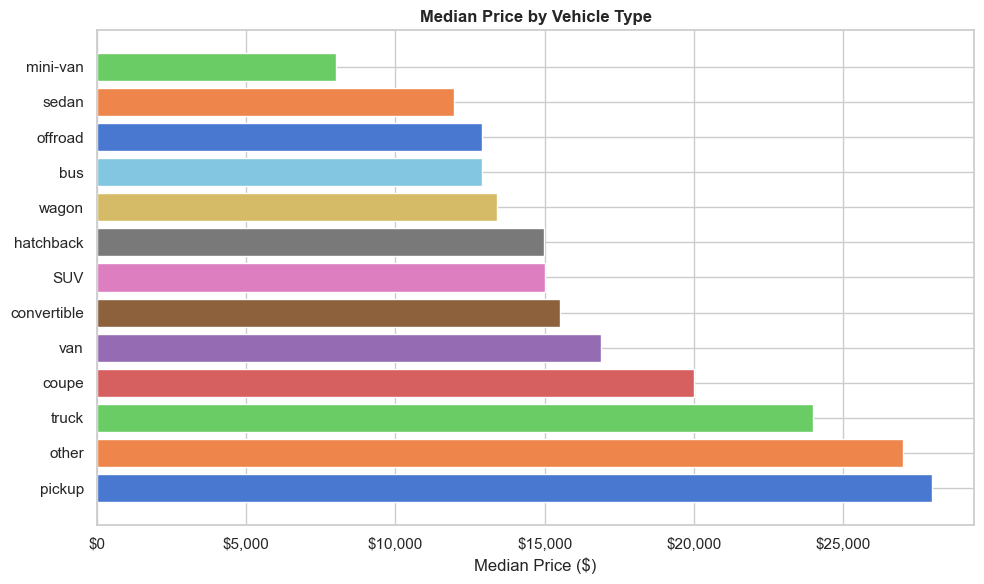

In [48]:
# Extract type coefficients and compare with median prices

type_coef = coef_df[coef_df['feature'].str.startswith('type_')].copy()
type_coef['type'] = type_coef['feature'].str.replace('type_', '')
type_coef = type_coef.sort_values('coefficient', ascending=False)
print("=== Vehicle Type Coefficients ===")
print(type_coef[['type', 'coefficient']].to_string(index=False))

# Median price by type
df_orig = pd.read_csv('data/vehicles.csv')
df_orig = df_orig[(df_orig['price'] >= 2000) & (df_orig['price'] <= 50000)]
type_median = df_orig.groupby('type')['price'].median().sort_values(ascending=False)
print("\n=== Median Price by Vehicle Type ===")
print(type_median)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(type_median.index, type_median.values,
        color=sns.color_palette('muted', len(type_median)))
ax.set_title('Median Price by Vehicle Type', fontweight='bold')
ax.set_xlabel('Median Price ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

#### Finding 3: Fuel Type Signals Value

The reference category for fuel type is **diesel** — all other fuel type coefficients represent the price difference relative to a diesel vehicle of the same age, mileage, and condition.

**Model Coefficients (relative to diesel):**
- **Diesel** — reference baseline, highest intrinsic value
- **Electric** — coefficient -0.041, slight discount vs diesel
- **Hybrid** — coefficient -0.065, moderate discount vs diesel
- **Other** — coefficient -0.104, significant discount vs diesel despite high median price
- **Gas** — coefficient -0.173, largest discount vs diesel

**Recommendation:** Diesel vehicles command the highest prices both in raw median price and after controlling for age and mileage. 
Electric vehicles also carry a strong median price ($23,990) with only a slight coefficient penalty relative to diesel — making them a solid inventory choice. Gas vehicles show the largest price discount across both measures and should be acquired at lower cost to maintain margins.







=== Fuel Type Coefficients ===
    fuel  coefficient
electric    -0.040760
  hybrid    -0.065257
   other    -0.103947
     gas    -0.172614

=== Median Price by Fuel Type ===
fuel
diesel      27490.0
other       26995.5
electric    23990.0
gas         13998.0
hybrid      12995.0
Name: price, dtype: float64


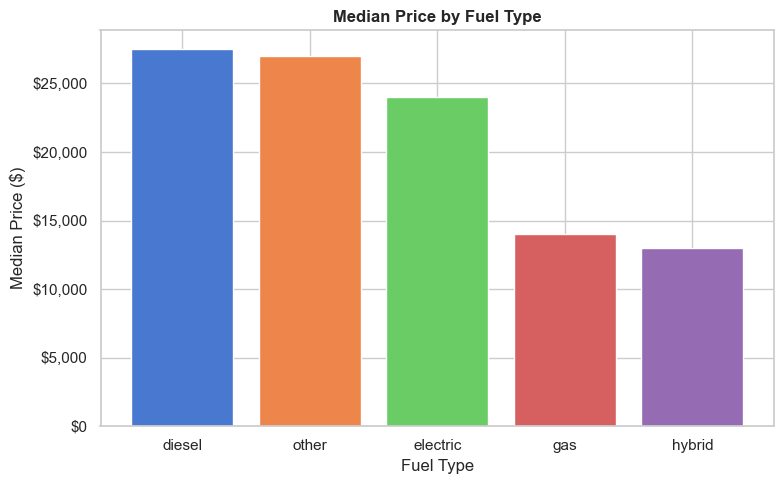

In [49]:
# Extract fuel coefficients and compare with median prices

fuel_coef = coef_df[coef_df['feature'].str.startswith('fuel_')].copy()
fuel_coef['fuel'] = fuel_coef['feature'].str.replace('fuel_', '')
fuel_coef = fuel_coef.sort_values('coefficient', ascending=False)
print("=== Fuel Type Coefficients ===")
print(fuel_coef[['fuel', 'coefficient']].to_string(index=False))

# Median price by fuel
df_orig = pd.read_csv('data/vehicles.csv')
df_orig = df_orig[(df_orig['price'] >= 2000) & (df_orig['price'] <= 50000)]
fuel_median = df_orig.groupby('fuel')['price'].median().sort_values(ascending=False)
print("\n=== Median Price by Fuel Type ===")
print(fuel_median)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fuel_median.index, fuel_median.values,
       color=sns.color_palette('muted', len(fuel_median)))
ax.set_title('Median Price by Fuel Type', fontweight='bold')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

#### Finding 4: Four-Wheel Drive Vehicles Command the Highest Prices

The reference category for drive type is **4WD**, all other drive type coefficients represent the price difference relative to a 4WD vehicle of the same age, mileage, and condition.

**Model Coefficients (relative to 4WD):**
- **4WD** — reference baseline, highest intrinsic value
- **RWD** — coefficient -0.001, virtually no discount vs 4WD
- **FWD** — coefficient -0.164, largest discount vs 4WD


**Recommendation:** 4WD and RWD vehicles command significantly higher prices than FWD vehicles both in raw median price and after controlling for age and
mileage. FWD vehicles (typically economy sedans and hatchbacks) carry an inherent price discount of 16% relative to 4WD vehicles even when in comparable condition. The dealership should prioritize 4WD and RWD inventory and be cautious about acquiring FWD vehicles unless at a sufficiently low cost to maintain healthy margins.

=== Drive Type Coefficients ===
drive  coefficient
  rwd    -0.001444
  fwd    -0.164106

=== Median Price by Drive Type ===
drive
4wd    19990.0
rwd    18990.0
fwd    10990.0
Name: price, dtype: float64


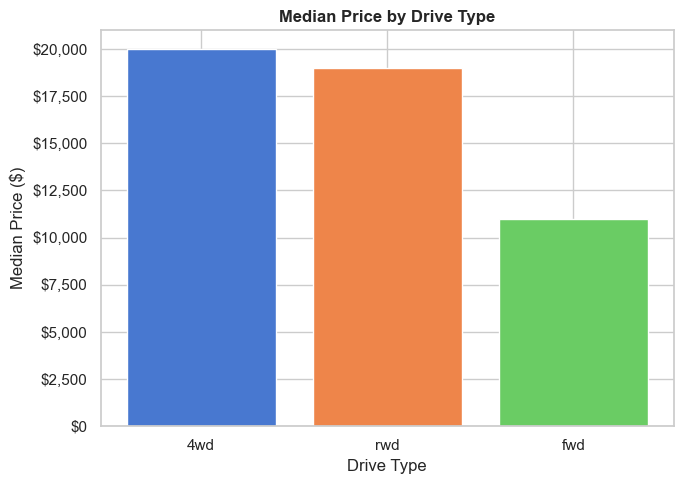

In [51]:
# Extract drive coefficients

drive_coef = coef_df[coef_df['feature'].str.startswith('drive_')].copy()
drive_coef['drive'] = drive_coef['feature'].str.replace('drive_', '')
drive_coef = drive_coef.sort_values('coefficient', ascending=False)
print("=== Drive Type Coefficients ===")
print(drive_coef[['drive', 'coefficient']].to_string(index=False))

# Median price by drive
df_orig = pd.read_csv('data/vehicles.csv')
df_orig = df_orig[(df_orig['price'] >= 2000) & (df_orig['price'] <= 50000)]
drive_median = df_orig.groupby('drive')['price'].median().sort_values(ascending=False)
print("\n=== Median Price by Drive Type ===")
print(drive_median)

# Visualize
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(drive_median.index, drive_median.values,
       color=sns.color_palette('muted', len(drive_median)))
ax.set_title('Median Price by Drive Type', fontweight='bold')
ax.set_xlabel('Drive Type')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

#### Finding 5: Title Status Has a Direct Impact on Resale Value

Title status has a clear and measurable impact on price.

**Median Market Prices by Title Status:**
- **Lien** — $17,000 (comparable to clean, just has an outstanding loan)
- **Clean** — $15,991 (standard baseline for most inventory)
- **Rebuilt** — $10,750 (~33% below clean title)
- **Salvage** — $7,999 (~50% below clean title)
- **Parts Only** — $5,500 (~66% below clean title)
- **Missing** — $4,500 (~72% below clean title)

**Recommendation:** Stock clean title vehicles exclusively for standard inventory as they command the highest and most consistent prices. Avoid salvage, parts only, and missing title vehicles unless the business specifically targets that niche.

=== Title Status Coefficient ===
Empty DataFrame
Columns: [feature, coefficient]
Index: []

=== Median Price by Title Status ===
title_status
lien          17000.0
clean         15991.0
rebuilt       10750.0
salvage        7999.0
parts only     5500.0
missing        4500.0
Name: price, dtype: float64


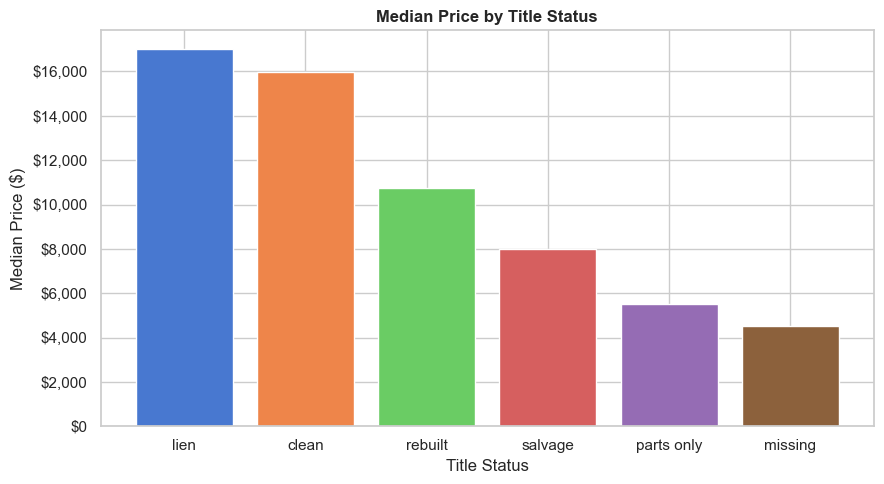

In [52]:
# title_status

title_coef = coef_df[coef_df['feature'] == 'title_status'][['feature', 'coefficient']]
print("=== Title Status Coefficient ===")
print(title_coef.to_string(index=False))

# Median price by title status
df_orig = pd.read_csv('data/vehicles.csv')
df_orig = df_orig[(df_orig['price'] >= 2000) & (df_orig['price'] <= 50000)]
title_median = df_orig.groupby('title_status')['price'].median().sort_values(ascending=False)
print("\n=== Median Price by Title Status ===")
print(title_median)

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(title_median.index, title_median.values,
       color=sns.color_palette('muted', len(title_median)))
ax.set_title('Median Price by Title Status', fontweight='bold')
ax.set_xlabel('Title Status')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

#### Finding 6: Manufacturer Has a Smaller Effect Than Expected

Manufacturer coefficients are relatively small compared to age, mileage, type, and drive type. This means that brand alone should not drive purchasing decisions.


**Recommendation:** Brand alone should not drive purchasing decisions. Focus on condition, age, type, and drive type first as these have far greater influence
on price.

=== Manufacturer Coefficients (highest to lowest) ===
   manufacturer  coefficient
          lexus     0.022433
        porsche     0.014092
          tesla     0.013943
   aston-martin     0.004436
        lincoln    -0.002144
harley-davidson    -0.002439
     land rover    -0.003387
          rover    -0.004489
       cadillac    -0.005883
         jaguar    -0.006412
     alfa-romeo    -0.007697
  mercedes-benz    -0.009836
       infiniti    -0.013444
           audi    -0.017918
          volvo    -0.019729
           mini    -0.022942
        pontiac    -0.023848
         toyota    -0.024190
            gmc    -0.025510
          buick    -0.025958
           fiat    -0.029635
        mercury    -0.029793
         saturn    -0.030265
            bmw    -0.032368
           jeep    -0.036908
          honda    -0.038989
            ram    -0.039016
       chrysler    -0.047347
          mazda    -0.047374
     volkswagen    -0.047510
     mitsubishi    -0.049093
          dodge   

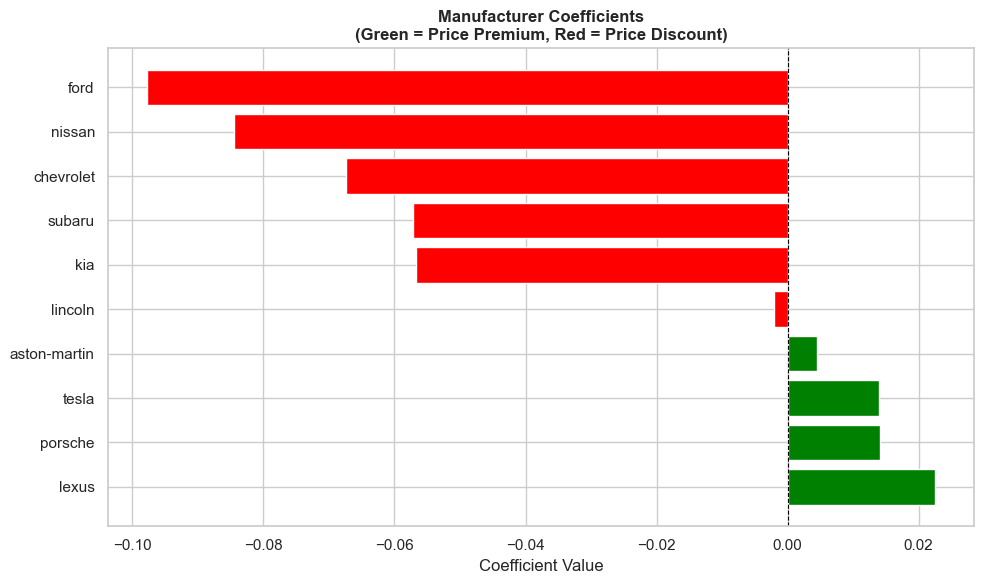

In [53]:
# Extract and sort manufacturer coefficients

mfr_coef = coef_df[coef_df['feature'].str.startswith('manufacturer_')].copy()
mfr_coef['manufacturer'] = mfr_coef['feature'].str.replace('manufacturer_', '')
mfr_coef = mfr_coef.sort_values('coefficient', ascending=False)
print("=== Manufacturer Coefficients (highest to lowest) ===")
print(mfr_coef[['manufacturer', 'coefficient']].to_string(index=False))

# Visualize top and bottom 10
top_bottom = pd.concat([mfr_coef.head(5), mfr_coef.tail(5)])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in top_bottom['coefficient']]
ax.barh(top_bottom['manufacturer'], top_bottom['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Manufacturer Coefficients\n(Green = Price Premium, Red = Price Discount)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### Executive Summary

This report presents the findings of a data-driven analysis of 135,566 used car listings to help your dealership make smarter inventory decisions. We identified the key factors that drive used car prices in the current market. Our model predicts used car prices within **$5,824 on average** against a median market price of **$15,590**.

---

#### What Makes a Used Car More Valuable?

**1. Age and Mileage Are Everything**
The single most important factors in used car pricing are how old the car is and how many miles it has been driven:

- **Every additional year of age** significantly reduces a car's value
- **Every additional mile on the odometer** further reduces the price
- Vehicles under **5 years old** with under **80,000 miles** command the strongest prices
- **Actionable advice:** Prioritize acquiring newer, low-mileage vehicles whenever possible.

---

**2. Stock Trucks and Pickups**
Vehicle type is one of the strongest predictors of price, independent of age and mileage:

- **Trucks and pickups** command the highest premiums (up to 12% above comparable SUVs)
- **SUVs** are a reliable baseline with strong and consistent demand
- **Convertibles and coupes** carry slight premiums but represent a smaller market
- **Sedans** are priced 6% below comparable SUVs even in identical condition
- **Mini-vans** have the lowest market prices despite not being inherently undervalued
- **Actionable advice:** Focus inventory on trucks, pickups, and SUVs.

---

**3. Prioritize Diesel and Electric Vehicles**
Fuel type has a measurable impact on price that goes beyond just market demand:

- **Diesel vehicles** command the highest prices — median of $27,490
- **Electric vehicles** follow closely at a median of $23,990 with strong buyer demand
- **Gas vehicles** show the largest price discount — median of $13,998
- **Hybrid vehicles** sit in the middle at a median of $12,995
- **Actionable advice:** Diesel trucks and electric vehicles are premium inventory worth acquiring at higher cost. Gas vehicles are the most common but least differentiated — margins will be tighter on these

---

**4. Four-Wheel Drive Commands a Premium**
The drive type significantly affects its value:

- **4WD vehicles** command the highest prices — median of $19,990
- **RWD vehicles** are priced almost identically to 4WD — median of $18,990
- **FWD vehicles** carry a 16% price discount even when in comparable condition — median of $10,990
- **Actionable advice:** Prioritize 4WD and RWD vehicles in your acquisition strategy. FWD vehicles should only be acquired at sufficiently low prices to compensate for their inherently lower resale value

---

**5. Always Verify Title Status Before Acquiring**
Title status has one of the most direct impacts on what a car can sell for:

- **Clean title** — $15,991 median, the standard for most inventory
- **Lien title** — $17,000 median, comparable to clean once the loan is resolved
- **Rebuilt title** — $10,750 median, a 33% discount vs clean title
- **Salvage title** — $7,999 median, a 50% discount vs clean title
- **Missing title** — $4,500 median, an 72% discount vs clean title
- **Actionable advice:** Stock clean title vehicles as your primary inventory. Lien title vehicles are safe to acquire — the financial complication is resolvable and they sell at clean title prices. Avoid salvage and missing title vehicles unless your business specifically targets budget buyers

---

**6. Brand Matters Less Than You Think**
Manufacturer has a small effect on price compared to age, mileage, type, and drive type:

- **Actionable advice:** Do not overpay for a vehicle simply because of its brand. Focus on condition, age, type, and drive type first.

---

#### Summary of Actionable Recommendations

- ✅ **Stock trucks, pickups, and SUVs** — they command the highest and most consistent prices
- ✅ **Prioritize newer vehicless** — age and mileage are the strongest price drivers
- ✅ **Seek out diesel and electric vehicles** — they fetch premium prices above comparable gas vehicles
- ✅ **Focus on 4WD and RWD vehicles** — FWD vehicles carry an inherent 16% price discount
- ✅ **Verify title status on every acquisition** — a salvage or missing title can cut a car's value in half
- ✅ **Do not overpay for brand** — condition, age, and type matter far more than the manufacturer badge

---

#### Model Performance

Our Ridge Regression model was trained on 135,566 used car listings and evaluated on a completely held-out test set it had never seen during training:

- **Test RMSE: $5,824** — average prediction error in dollar terms
- **Median market price: $15,590**
- **Model consistency:** CV MSE (0.1145) ≈ Validation MSE (0.1145) ≈ Test MSE (0.1173) confirming no overfitting

---

#### Limitations and Next Steps

- The model performs best for mainstream used cars priced between $2,000 and $50,000 — predictions outside this range are less reliable
- Adding more features such as number of cylinders and paint color with better data collection could further improve accuracy